In [1]:
from IPython.display import display, HTML
display(HTML("""
<style>
div.container{width:95% !important;}
div.cell.code_cell.rendered{width:95%;}
div.input_prompt{padding:0px;}
div.CodeMirror {font-family:Consolas; font-size:20pt;}
.inner_cell{font-size:20pt;}
div.text_cell_render pre code {font-size:20pt; line-height:30px;}
div.output {font-size:20pt; font-weight:bold;}
div.input {font-family:Consolas; font-size:20pt;}
div.prompt {min-width:70px;}
div#toc-wrapper{padding-top:120px;}
div.text_cell_render ul li{font-size:20pt;padding:5px;}
table.dataframe{font-size:20px;}
</style>
"""))

<b><font color="red" size="6"></font></b>

In [5]:
#GPU 활성화 끄기
# import os
#os.environ['CUDA_VISIBLE_DEVICES'] = "-1"
#GPU 사용 여부 확인
import tensorflow as tf
print(tf.__version__)
tf.config.list_physical_devices('GPU')


2.10.0


[]

# 1. 기존의 프로그램 방식

In [6]:
import numpy as np
import matplotlib.pyplot as plt

In [8]:
#섭씨온도(input data)를 받아 화씨 온도로 출력
def celsius_to_faherenheit(c):
    return 1.8*c+32

In [9]:
input_data=int(input('섭씨온도는?'))
print('화씨온도는 ', celsius_to_faherenheit(input_data))

섭씨온도는?10
화씨온도는  50.0


# 2. 머신러닝/딥러닝 프로그램 방식
- 1. 데이터 확보 및 생성
- 2. 데이터 전처리 : scale조정, 라벨링처리, 훈련데이터셋(학습데이터셋), 검증데이터셋, 시험데이터셋으로 나누기
- 3. 모델구성
- 4. 모델 학습과정 설정
- 5. 모델 학습시키기(학습데이터셋과 검증데이터셋으로)
- 6. 모델 평가(시험데이터셋으로)
- 7. 모델 사용(입력값이 주어지면 예측값을 받기)
## 2.1 노이즈가 없는 데이터로 실습

In [10]:
# 1. 데이터 생성
data_C=np.arange(100)
data_C #입력변수 (독립변수)

array([ 0,  1,  2,  3,  4,  5,  6,  7,  8,  9, 10, 11, 12, 13, 14, 15, 16,
       17, 18, 19, 20, 21, 22, 23, 24, 25, 26, 27, 28, 29, 30, 31, 32, 33,
       34, 35, 36, 37, 38, 39, 40, 41, 42, 43, 44, 45, 46, 47, 48, 49, 50,
       51, 52, 53, 54, 55, 56, 57, 58, 59, 60, 61, 62, 63, 64, 65, 66, 67,
       68, 69, 70, 71, 72, 73, 74, 75, 76, 77, 78, 79, 80, 81, 82, 83, 84,
       85, 86, 87, 88, 89, 90, 91, 92, 93, 94, 95, 96, 97, 98, 99])

In [11]:
data_F=celsius_to_faherenheit(data_C)
data_F # 타겟변수 (종속변수)

array([ 32. ,  33.8,  35.6,  37.4,  39.2,  41. ,  42.8,  44.6,  46.4,
        48.2,  50. ,  51.8,  53.6,  55.4,  57.2,  59. ,  60.8,  62.6,
        64.4,  66.2,  68. ,  69.8,  71.6,  73.4,  75.2,  77. ,  78.8,
        80.6,  82.4,  84.2,  86. ,  87.8,  89.6,  91.4,  93.2,  95. ,
        96.8,  98.6, 100.4, 102.2, 104. , 105.8, 107.6, 109.4, 111.2,
       113. , 114.8, 116.6, 118.4, 120.2, 122. , 123.8, 125.6, 127.4,
       129.2, 131. , 132.8, 134.6, 136.4, 138.2, 140. , 141.8, 143.6,
       145.4, 147.2, 149. , 150.8, 152.6, 154.4, 156.2, 158. , 159.8,
       161.6, 163.4, 165.2, 167. , 168.8, 170.6, 172.4, 174.2, 176. ,
       177.8, 179.6, 181.4, 183.2, 185. , 186.8, 188.6, 190.4, 192.2,
       194. , 195.8, 197.6, 199.4, 201.2, 203. , 204.8, 206.6, 208.4,
       210.2])

In [16]:
#2. 데이터 전처리 : 컴퓨터에게 학습시키기 위해, Normalize(변수들의 편차를 비슷하게)
scaled_data_C=data_C/100.0
scaled_data_F=data_F/100.0
print('독립변수 ' , scaled_data_C)
print('종속변수 ' , scaled_data_F)

독립변수  [0.   0.01 0.02 0.03 0.04 0.05 0.06 0.07 0.08 0.09 0.1  0.11 0.12 0.13
 0.14 0.15 0.16 0.17 0.18 0.19 0.2  0.21 0.22 0.23 0.24 0.25 0.26 0.27
 0.28 0.29 0.3  0.31 0.32 0.33 0.34 0.35 0.36 0.37 0.38 0.39 0.4  0.41
 0.42 0.43 0.44 0.45 0.46 0.47 0.48 0.49 0.5  0.51 0.52 0.53 0.54 0.55
 0.56 0.57 0.58 0.59 0.6  0.61 0.62 0.63 0.64 0.65 0.66 0.67 0.68 0.69
 0.7  0.71 0.72 0.73 0.74 0.75 0.76 0.77 0.78 0.79 0.8  0.81 0.82 0.83
 0.84 0.85 0.86 0.87 0.88 0.89 0.9  0.91 0.92 0.93 0.94 0.95 0.96 0.97
 0.98 0.99]
종속변수  [0.32  0.338 0.356 0.374 0.392 0.41  0.428 0.446 0.464 0.482 0.5   0.518
 0.536 0.554 0.572 0.59  0.608 0.626 0.644 0.662 0.68  0.698 0.716 0.734
 0.752 0.77  0.788 0.806 0.824 0.842 0.86  0.878 0.896 0.914 0.932 0.95
 0.968 0.986 1.004 1.022 1.04  1.058 1.076 1.094 1.112 1.13  1.148 1.166
 1.184 1.202 1.22  1.238 1.256 1.274 1.292 1.31  1.328 1.346 1.364 1.382
 1.4   1.418 1.436 1.454 1.472 1.49  1.508 1.526 1.544 1.562 1.58  1.598
 1.616 1.634 1.652 1.67  1.688 1.706 1.724

In [19]:
# 3. 모델 구성(tensorflow)
from tensorflow.keras.models import Sequential #모델 생성 
from tensorflow.keras.layers import Dense #입력값과 출력값으로 layer층 지정
model = Sequential()
model.add(Dense(1, #출력(종속,타겟)변수의 갯수
            input_shape=(1,)  #입력(독립)변수의 shape
               ))
print(model.summary())

Model: "sequential_2"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 dense_1 (Dense)             (None, 1)                 2         
                                                                 
Total params: 2
Trainable params: 2
Non-trainable params: 0
_________________________________________________________________
None


- 회귀분석 오차함수 : 
        MSE(오차제곱평균), RMSE(루트를 취하기 때문에 MSE단점이 어느정도 해소. 덜 민감, MAE(절대값평균)

In [20]:
# 4. 모델 학습 과정 설정
model.compile(loss='mse', optimizer='rmsprop',metrics=['mae'])
               # 손실함수        옵티마이저        평가지표
    
# loss(오차,손실함수)는 모델 학습중 최정화할 대상
#metrics : 평가지표

In [22]:
# 학습 전 예측
model.predict(np.array([[0],[0.01]]))

1/1 [==============================] - 0s 121ms/step


array([[0.        ],
       [0.00634573]], dtype=float32)

In [23]:
# 학습전 모델 저장
model.save('model/before_learning.h5') # kernel에 w(기울기), bias에 b이 있음
# from tensorflow.keras.models import save_model
# save_model(model,'model/before_learning.h5')

In [24]:
# 모델 학습시키기 - 1번만 실행 
hist = model.fit(scaled_data_C, scaled_data_F, epochs=1000, verbose=2)
                  # 독립변수     # 타겟변수(종속)    학습횟수        학습시 출력여부


Epoch 1/1000
4/4 - 0s - loss: 0.9084 - mae: 0.8923 - 454ms/epoch - 114ms/step
Epoch 2/1000
4/4 - 0s - loss: 0.8859 - mae: 0.8803 - 9ms/epoch - 2ms/step
Epoch 3/1000
4/4 - 0s - loss: 0.8714 - mae: 0.8725 - 6ms/epoch - 2ms/step
Epoch 4/1000
4/4 - 0s - loss: 0.8591 - mae: 0.8659 - 7ms/epoch - 2ms/step
Epoch 5/1000
4/4 - 0s - loss: 0.8472 - mae: 0.8595 - 6ms/epoch - 2ms/step
Epoch 6/1000
4/4 - 0s - loss: 0.8355 - mae: 0.8532 - 6ms/epoch - 1ms/step
Epoch 7/1000
4/4 - 0s - loss: 0.8246 - mae: 0.8471 - 7ms/epoch - 2ms/step
Epoch 8/1000
4/4 - 0s - loss: 0.8148 - mae: 0.8418 - 5ms/epoch - 1ms/step
Epoch 9/1000
4/4 - 0s - loss: 0.8037 - mae: 0.8356 - 5ms/epoch - 1ms/step
Epoch 10/1000
4/4 - 0s - loss: 0.7936 - mae: 0.8300 - 6ms/epoch - 2ms/step
Epoch 11/1000
4/4 - 0s - loss: 0.7840 - mae: 0.8245 - 6ms/epoch - 2ms/step
Epoch 12/1000
4/4 - 0s - loss: 0.7734 - mae: 0.8184 - 7ms/epoch - 2ms/step
Epoch 13/1000
4/4 - 0s - loss: 0.7645 - mae: 0.8135 - 6ms/epoch - 2ms/step
Epoch 14/1000
4/4 - 0s - loss:

Epoch 110/1000
4/4 - 0s - loss: 0.1122 - mae: 0.2748 - 6ms/epoch - 1ms/step
Epoch 111/1000
4/4 - 0s - loss: 0.1089 - mae: 0.2705 - 7ms/epoch - 2ms/step
Epoch 112/1000
4/4 - 0s - loss: 0.1059 - mae: 0.2665 - 4ms/epoch - 1ms/step
Epoch 113/1000
4/4 - 0s - loss: 0.1030 - mae: 0.2628 - 6ms/epoch - 1ms/step
Epoch 114/1000
4/4 - 0s - loss: 0.1000 - mae: 0.2588 - 5ms/epoch - 1ms/step
Epoch 115/1000
4/4 - 0s - loss: 0.0971 - mae: 0.2548 - 6ms/epoch - 1ms/step
Epoch 116/1000
4/4 - 0s - loss: 0.0936 - mae: 0.2500 - 5ms/epoch - 1ms/step
Epoch 117/1000
4/4 - 0s - loss: 0.0910 - mae: 0.2465 - 6ms/epoch - 1ms/step
Epoch 118/1000
4/4 - 0s - loss: 0.0882 - mae: 0.2426 - 4ms/epoch - 990us/step
Epoch 119/1000
4/4 - 0s - loss: 0.0852 - mae: 0.2383 - 6ms/epoch - 2ms/step
Epoch 120/1000
4/4 - 0s - loss: 0.0825 - mae: 0.2344 - 5ms/epoch - 1ms/step
Epoch 121/1000
4/4 - 0s - loss: 0.0798 - mae: 0.2307 - 5ms/epoch - 1ms/step
Epoch 122/1000
4/4 - 0s - loss: 0.0770 - mae: 0.2267 - 6ms/epoch - 2ms/step
Epoch 123/

Epoch 218/1000
4/4 - 0s - loss: 0.0116 - mae: 0.0929 - 5ms/epoch - 1ms/step
Epoch 219/1000
4/4 - 0s - loss: 0.0113 - mae: 0.0919 - 8ms/epoch - 2ms/step
Epoch 220/1000
4/4 - 0s - loss: 0.0111 - mae: 0.0910 - 5ms/epoch - 1ms/step
Epoch 221/1000
4/4 - 0s - loss: 0.0109 - mae: 0.0903 - 6ms/epoch - 2ms/step
Epoch 222/1000
4/4 - 0s - loss: 0.0107 - mae: 0.0895 - 5ms/epoch - 1ms/step
Epoch 223/1000
4/4 - 0s - loss: 0.0106 - mae: 0.0887 - 6ms/epoch - 2ms/step
Epoch 224/1000
4/4 - 0s - loss: 0.0103 - mae: 0.0879 - 6ms/epoch - 1ms/step
Epoch 225/1000
4/4 - 0s - loss: 0.0102 - mae: 0.0870 - 5ms/epoch - 1ms/step
Epoch 226/1000
4/4 - 0s - loss: 0.0100 - mae: 0.0861 - 5ms/epoch - 1ms/step
Epoch 227/1000
4/4 - 0s - loss: 0.0098 - mae: 0.0854 - 5ms/epoch - 1ms/step
Epoch 228/1000
4/4 - 0s - loss: 0.0096 - mae: 0.0845 - 14ms/epoch - 3ms/step
Epoch 229/1000
4/4 - 0s - loss: 0.0094 - mae: 0.0837 - 8ms/epoch - 2ms/step
Epoch 230/1000
4/4 - 0s - loss: 0.0092 - mae: 0.0828 - 5ms/epoch - 1ms/step
Epoch 231/1

Epoch 325/1000
4/4 - 0s - loss: 8.8989e-05 - mae: 0.0080 - 5ms/epoch - 1ms/step
Epoch 326/1000
4/4 - 0s - loss: 7.4981e-05 - mae: 0.0074 - 5ms/epoch - 1ms/step
Epoch 327/1000
4/4 - 0s - loss: 6.3738e-05 - mae: 0.0069 - 6ms/epoch - 1ms/step
Epoch 328/1000
4/4 - 0s - loss: 5.0373e-05 - mae: 0.0061 - 5ms/epoch - 1ms/step
Epoch 329/1000
4/4 - 0s - loss: 4.0266e-05 - mae: 0.0054 - 5ms/epoch - 1ms/step
Epoch 330/1000
4/4 - 0s - loss: 3.3647e-05 - mae: 0.0050 - 5ms/epoch - 1ms/step
Epoch 331/1000
4/4 - 0s - loss: 2.5391e-05 - mae: 0.0044 - 7ms/epoch - 2ms/step
Epoch 332/1000
4/4 - 0s - loss: 1.9871e-05 - mae: 0.0038 - 5ms/epoch - 1ms/step
Epoch 333/1000
4/4 - 0s - loss: 1.4202e-05 - mae: 0.0032 - 6ms/epoch - 1ms/step
Epoch 334/1000
4/4 - 0s - loss: 9.7802e-06 - mae: 0.0027 - 5ms/epoch - 1ms/step
Epoch 335/1000
4/4 - 0s - loss: 7.1457e-06 - mae: 0.0023 - 7ms/epoch - 2ms/step
Epoch 336/1000
4/4 - 0s - loss: 4.7760e-06 - mae: 0.0018 - 5ms/epoch - 1ms/step
Epoch 337/1000
4/4 - 0s - loss: 2.3987e-

Epoch 424/1000
4/4 - 0s - loss: 1.2317e-06 - mae: 0.0010 - 5ms/epoch - 1ms/step
Epoch 425/1000
4/4 - 0s - loss: 1.3674e-06 - mae: 9.4870e-04 - 6ms/epoch - 2ms/step
Epoch 426/1000
4/4 - 0s - loss: 4.9364e-09 - mae: 6.3969e-05 - 6ms/epoch - 1ms/step
Epoch 427/1000
4/4 - 0s - loss: 1.3249e-09 - mae: 3.2749e-05 - 6ms/epoch - 1ms/step
Epoch 428/1000
4/4 - 0s - loss: 1.8234e-08 - mae: 1.2062e-04 - 5ms/epoch - 1ms/step
Epoch 429/1000
4/4 - 0s - loss: 1.5305e-06 - mae: 0.0011 - 5ms/epoch - 1ms/step
Epoch 430/1000
4/4 - 0s - loss: 4.6184e-07 - mae: 6.4732e-04 - 5ms/epoch - 1ms/step
Epoch 431/1000
4/4 - 0s - loss: 2.1057e-07 - mae: 4.4919e-04 - 5ms/epoch - 1ms/step
Epoch 432/1000
4/4 - 0s - loss: 4.8987e-07 - mae: 6.7836e-04 - 5ms/epoch - 1ms/step
Epoch 433/1000
4/4 - 0s - loss: 1.1370e-06 - mae: 0.0010 - 5ms/epoch - 1ms/step
Epoch 434/1000
4/4 - 0s - loss: 2.7235e-07 - mae: 5.1099e-04 - 6ms/epoch - 2ms/step
Epoch 435/1000
4/4 - 0s - loss: 2.2606e-07 - mae: 4.5998e-04 - 4ms/epoch - 1ms/step
Epoc

Epoch 523/1000
4/4 - 0s - loss: 1.1091e-06 - mae: 0.0010 - 7ms/epoch - 2ms/step
Epoch 524/1000
4/4 - 0s - loss: 8.3238e-07 - mae: 8.7115e-04 - 6ms/epoch - 1ms/step
Epoch 525/1000
4/4 - 0s - loss: 9.1580e-08 - mae: 2.9749e-04 - 6ms/epoch - 2ms/step
Epoch 526/1000
4/4 - 0s - loss: 4.4773e-07 - mae: 6.4173e-04 - 5ms/epoch - 1ms/step
Epoch 527/1000
4/4 - 0s - loss: 1.0401e-06 - mae: 9.9523e-04 - 5ms/epoch - 1ms/step
Epoch 528/1000
4/4 - 0s - loss: 2.0312e-07 - mae: 4.4205e-04 - 6ms/epoch - 1ms/step
Epoch 529/1000
4/4 - 0s - loss: 2.6071e-07 - mae: 4.8972e-04 - 4ms/epoch - 1ms/step
Epoch 530/1000
4/4 - 0s - loss: 1.4653e-06 - mae: 0.0012 - 4ms/epoch - 1ms/step
Epoch 531/1000
4/4 - 0s - loss: 2.1486e-07 - mae: 4.3942e-04 - 5ms/epoch - 1ms/step
Epoch 532/1000
4/4 - 0s - loss: 3.4346e-07 - mae: 5.7341e-04 - 6ms/epoch - 1ms/step
Epoch 533/1000
4/4 - 0s - loss: 1.1386e-06 - mae: 0.0010 - 5ms/epoch - 1ms/step
Epoch 534/1000
4/4 - 0s - loss: 2.2370e-07 - mae: 4.6380e-04 - 5ms/epoch - 1ms/step
Epoc

4/4 - 0s - loss: 2.0674e-07 - mae: 4.3463e-04 - 5ms/epoch - 1ms/step
Epoch 622/1000
4/4 - 0s - loss: 9.0275e-07 - mae: 9.2195e-04 - 6ms/epoch - 2ms/step
Epoch 623/1000
4/4 - 0s - loss: 7.4064e-07 - mae: 8.4221e-04 - 6ms/epoch - 1ms/step
Epoch 624/1000
4/4 - 0s - loss: 2.6515e-07 - mae: 5.0550e-04 - 6ms/epoch - 1ms/step
Epoch 625/1000
4/4 - 0s - loss: 6.7391e-07 - mae: 8.0586e-04 - 4ms/epoch - 1ms/step
Epoch 626/1000
4/4 - 0s - loss: 4.6878e-07 - mae: 6.7033e-04 - 6ms/epoch - 1ms/step
Epoch 627/1000
4/4 - 0s - loss: 7.5343e-08 - mae: 2.4844e-04 - 6ms/epoch - 1ms/step
Epoch 628/1000
4/4 - 0s - loss: 1.0884e-06 - mae: 9.9324e-04 - 7ms/epoch - 2ms/step
Epoch 629/1000
4/4 - 0s - loss: 1.1348e-06 - mae: 9.4919e-04 - 4ms/epoch - 995us/step
Epoch 630/1000
4/4 - 0s - loss: 2.9328e-08 - mae: 1.6334e-04 - 6ms/epoch - 1ms/step
Epoch 631/1000
4/4 - 0s - loss: 5.0181e-08 - mae: 2.1432e-04 - 4ms/epoch - 1ms/step
Epoch 632/1000
4/4 - 0s - loss: 9.6839e-07 - mae: 9.3188e-04 - 6ms/epoch - 1ms/step
Epoch

Epoch 720/1000
4/4 - 0s - loss: 5.1474e-07 - mae: 6.9412e-04 - 6ms/epoch - 1ms/step
Epoch 721/1000
4/4 - 0s - loss: 8.8947e-07 - mae: 9.2166e-04 - 4ms/epoch - 1ms/step
Epoch 722/1000
4/4 - 0s - loss: 7.4967e-07 - mae: 8.3429e-04 - 6ms/epoch - 1ms/step
Epoch 723/1000
4/4 - 0s - loss: 8.8415e-08 - mae: 2.9225e-04 - 5ms/epoch - 1ms/step
Epoch 724/1000
4/4 - 0s - loss: 2.9776e-07 - mae: 5.1691e-04 - 5ms/epoch - 1ms/step
Epoch 725/1000
4/4 - 0s - loss: 1.4674e-06 - mae: 0.0012 - 5ms/epoch - 1ms/step
Epoch 726/1000
4/4 - 0s - loss: 1.7878e-07 - mae: 4.1362e-04 - 5ms/epoch - 1ms/step
Epoch 727/1000
4/4 - 0s - loss: 3.0476e-07 - mae: 5.3588e-04 - 6ms/epoch - 2ms/step
Epoch 728/1000
4/4 - 0s - loss: 1.2420e-06 - mae: 0.0011 - 5ms/epoch - 1ms/step
Epoch 729/1000
4/4 - 0s - loss: 6.0049e-07 - mae: 7.4319e-04 - 7ms/epoch - 2ms/step
Epoch 730/1000
4/4 - 0s - loss: 4.7656e-08 - mae: 2.1351e-04 - 5ms/epoch - 1ms/step
Epoch 731/1000
4/4 - 0s - loss: 6.5053e-07 - mae: 7.6659e-04 - 6ms/epoch - 1ms/step


Epoch 818/1000
4/4 - 0s - loss: 4.4573e-07 - mae: 6.4200e-04 - 5ms/epoch - 1ms/step
Epoch 819/1000
4/4 - 0s - loss: 2.1352e-07 - mae: 4.4951e-04 - 5ms/epoch - 1ms/step
Epoch 820/1000
4/4 - 0s - loss: 2.7209e-07 - mae: 4.8988e-04 - 6ms/epoch - 1ms/step
Epoch 821/1000
4/4 - 0s - loss: 1.3389e-06 - mae: 0.0011 - 5ms/epoch - 1ms/step
Epoch 822/1000
4/4 - 0s - loss: 4.9950e-07 - mae: 6.5612e-04 - 7ms/epoch - 2ms/step
Epoch 823/1000
4/4 - 0s - loss: 2.0504e-07 - mae: 4.3715e-04 - 7ms/epoch - 2ms/step
Epoch 824/1000
4/4 - 0s - loss: 4.4419e-07 - mae: 6.4325e-04 - 7ms/epoch - 2ms/step
Epoch 825/1000
4/4 - 0s - loss: 1.4314e-06 - mae: 0.0011 - 4ms/epoch - 1ms/step
Epoch 826/1000
4/4 - 0s - loss: 1.5350e-07 - mae: 3.7307e-04 - 5ms/epoch - 1ms/step
Epoch 827/1000
4/4 - 0s - loss: 1.8416e-07 - mae: 4.1275e-04 - 6ms/epoch - 1ms/step
Epoch 828/1000
4/4 - 0s - loss: 1.4144e-06 - mae: 0.0012 - 6ms/epoch - 1ms/step
Epoch 829/1000
4/4 - 0s - loss: 1.9651e-07 - mae: 4.3090e-04 - 5ms/epoch - 1ms/step
Epoc

Epoch 917/1000
4/4 - 0s - loss: 2.7046e-07 - mae: 5.0792e-04 - 7ms/epoch - 2ms/step
Epoch 918/1000
4/4 - 0s - loss: 4.1415e-07 - mae: 6.2314e-04 - 5ms/epoch - 1ms/step
Epoch 919/1000
4/4 - 0s - loss: 6.1899e-07 - mae: 7.7120e-04 - 5ms/epoch - 1ms/step
Epoch 920/1000
4/4 - 0s - loss: 8.4299e-07 - mae: 8.7818e-04 - 4ms/epoch - 1ms/step
Epoch 921/1000
4/4 - 0s - loss: 4.8978e-07 - mae: 6.8658e-04 - 6ms/epoch - 1ms/step
Epoch 922/1000
4/4 - 0s - loss: 7.2593e-07 - mae: 8.3473e-04 - 6ms/epoch - 1ms/step
Epoch 923/1000
4/4 - 0s - loss: 4.5172e-07 - mae: 6.5959e-04 - 6ms/epoch - 2ms/step
Epoch 924/1000
4/4 - 0s - loss: 4.0524e-07 - mae: 6.2336e-04 - 5ms/epoch - 1ms/step
Epoch 925/1000
4/4 - 0s - loss: 1.0427e-06 - mae: 9.9395e-04 - 7ms/epoch - 2ms/step
Epoch 926/1000
4/4 - 0s - loss: 4.2182e-07 - mae: 6.3204e-04 - 5ms/epoch - 1ms/step
Epoch 927/1000
4/4 - 0s - loss: 3.4712e-07 - mae: 5.7386e-04 - 7ms/epoch - 2ms/step
Epoch 928/1000
4/4 - 0s - loss: 3.1964e-07 - mae: 5.4498e-04 - 5ms/epoch - 1

In [29]:
hist.history.keys()

dict_keys(['loss', 'mae'])

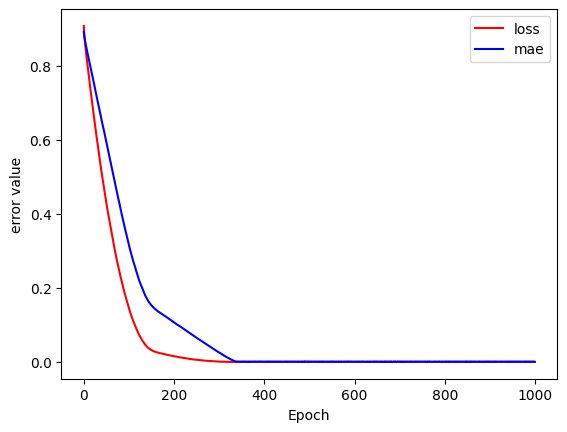

In [36]:
plt.plot(hist.history['loss'],'r', label='loss')
plt.plot(hist.history['mae'],'b', label='mae')
plt.xlabel('Epoch')
plt.ylabel('error value')
plt.legend()


In [37]:
# 모델사용하기
model.predict(np.array([[0],[0.01],[0.02]]))

1/1 [==============================] - 0s 20ms/step


array([[0.3191991 ],
       [0.33719173],
       [0.35518438]], dtype=float32)

In [38]:
model.save('model/after_learning.h5')